# Задание 3: Обучение ранжированию


1. `CatBoost` на LETOR-данных `MSRank_10K`.
2. `Обучение ранжированию` на `Internet Mathematics 2009`.
3. Переранжирование для `WikIR` поверх `BM25`.
4. Переранжирование для `MIRAGE` с дополнительными признаками.


In [1]:
import json
import math
import pickle
import re
import warnings
from concurrent.futures import ThreadPoolExecutor
from collections import Counter, defaultdict
from pathlib import Path
from urllib.parse import quote, unquote, urlparse

import ir_measures
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from catboost import CatBoostRanker, Pool
from datasets import load_dataset
from ir_measures import AP, P, nDCG
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)


/Users/maksimpiskaev/Проекты/IR/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
HW3_DIR = Path('.')
DATA_DIR = HW3_DIR / 'data'
CACHE_DIR = HW3_DIR / 'cache'
RUNS_DIR = HW3_DIR / 'runs'
CACHE_DIR.mkdir(exist_ok=True)
RUNS_DIR.mkdir(exist_ok=True)

WIKIR_DIR = Path('../HW_1/data/wikIR1k')
IMAT_DIR = HW3_DIR / 'imat2009_new_split'

# Полный прогон ноутбука для финальных метрик.
FAST_DEBUG = False
CACHE_TAG = 'fast' if FAST_DEBUG else 'full'

WIKIR_TRAIN_QUERY_LIMIT = 50 if FAST_DEBUG else None
WIKIR_BM25_TRAIN_TOP_K = 10 if FAST_DEBUG else 100
WIKIR_BM25_TEST_TOP_K = 30 if FAST_DEBUG else 100
WIKIR_NEGATIVES_PER_POSITIVE = 0.25 if FAST_DEBUG else 1.0

MIRAGE_TRAIN_QUERY_LIMIT = 300 if FAST_DEBUG else None
MIRAGE_TEST_QUERY_LIMIT = 300 if FAST_DEBUG else None
MIRAGE_USE_PAGE_SIGNALS = False if FAST_DEBUG else True



## Общие функции

Сначала определим набор вспомогательных функций для:
- парсинга LETOR-подобных файлов;
- обучения `CatBoostRanker`;
- вычисления `nDCG@10`;
- построения BM25/TF-IDF признаков;
- подготовки runs и оценки через `ir-measures`.


In [3]:
TOKEN_RE = re.compile(r"[A-Za-z0-9_]+")


def simple_tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())



def load_or_build_pickle(path: str | Path, builder):
    path = Path(path)
    if path.exists():
        with open(path, 'rb') as f:
            return pickle.load(f)
    obj = builder()
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    return obj



def save_pickle(path: str | Path, obj):
    path = Path(path)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    return path



def load_or_train_catboost(model_path: str | Path, train_df: pd.DataFrame, feature_cols: list[str], valid_df: pd.DataFrame | None = None, **kwargs):
    model_path = Path(model_path)
    if model_path.exists():
        model = CatBoostRanker()
        model.load_model(str(model_path))
        return model

    model = train_catboost_ranker(
        train_df,
        feature_cols,
        valid_df,
        **kwargs,
    )
    model.save_model(str(model_path))
    return model



def dcg_at_k(rels, k: int) -> float:
    rels = list(rels)[:k]
    total = 0.0
    for idx, rel in enumerate(rels, start=1):
        total += (2 ** rel - 1) / math.log2(idx + 1)
    return total



def mean_ndcg_at_k(df: pd.DataFrame, score_col: str, k: int = 10) -> float:
    ndcgs = []
    for _, group in df.groupby('qid'):
        ranked = group.sort_values(score_col, ascending=False)
        ideal = group.sort_values('label', ascending=False)
        ideal_dcg = dcg_at_k(ideal['label'].tolist(), k)
        if ideal_dcg == 0:
            ndcgs.append(0.0)
        else:
            ndcgs.append(dcg_at_k(ranked['label'].tolist(), k) / ideal_dcg)
    return float(np.mean(ndcgs))



def parse_msrank_dataset(path: str | Path):
    df = pd.read_csv(path, header=None)
    feature_cols = [f'f_{i}' for i in range(1, df.shape[1] - 1)]
    df.columns = ['label', 'qid', *feature_cols]
    df['qid'] = df['qid'].astype(str)
    df['doc_id'] = df.groupby('qid').cumcount().map(lambda x: f'D{x}')
    return df[['label', 'qid', 'doc_id', *feature_cols]], feature_cols



def parse_imat2009_file(path: str | Path):
    rows = []
    feature_ids = set()
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            main, comment = (line.split('#', 1) + [''])[:2]
            qid = comment.strip() or 'unknown'
            parts = main.split()
            label = int(float(parts[0]))
            feature_map = {}
            for token in parts[1:]:
                if ':' not in token:
                    continue
                feat_id, value = token.split(':', 1)
                feature_map[f'f_{feat_id}'] = float(value)
                feature_ids.add(int(feat_id))
            rows.append({'label': label, 'qid': qid, **feature_map})

    feature_cols = [f'f_{i}' for i in sorted(feature_ids)]
    df = pd.DataFrame(rows)
    for feature in feature_cols:
        if feature not in df.columns:
            df[feature] = 0.0
    df = df.fillna(0.0)
    df['doc_id'] = df.groupby('qid').cumcount().map(lambda x: f'D{x}')
    return df[['label', 'qid', 'doc_id', *feature_cols]], feature_cols



def align_feature_columns(df: pd.DataFrame, feature_cols: list[str]):
    result = df.copy()
    for feature in feature_cols:
        if feature not in result.columns:
            result[feature] = 0.0
    return result[['label', 'qid', 'doc_id', *feature_cols]]



def write_letor_file(df: pd.DataFrame, feature_cols: list[str], path: str | Path):
    path = Path(path)
    df = align_feature_columns(df, feature_cols)
    lines = []
    for row in df.itertuples(index=False):
        features = ' '.join(
            f'{idx}:{getattr(row, feature):.6f}'
            for idx, feature in enumerate(feature_cols, start=1)
        )
        lines.append(f'{int(row.label)} qid:{row.qid} {features} # {row.doc_id}')
    path.write_text('\n'.join(lines) + '\n', encoding='utf-8')
    return path



def train_catboost_ranker(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    valid_df: pd.DataFrame | None = None,
    *,
    loss_function: str = 'YetiRank',
    eval_metric: str = 'NDCG:top=10',
    iterations: int = 60,
    learning_rate: float = 0.08,
    depth: int = 6,
    random_seed: int = 42,
):
    train_pool = Pool(
        train_df[feature_cols],
        label=train_df['label'],
        group_id=train_df['qid'],
    )
    eval_set = None
    if valid_df is not None:
        eval_set = Pool(
            valid_df[feature_cols],
            label=valid_df['label'],
            group_id=valid_df['qid'],
        )

    model = CatBoostRanker(
        loss_function=loss_function,
        eval_metric=eval_metric,
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        random_seed=random_seed,
        verbose=False,
    )
    model.fit(train_pool, eval_set=eval_set, use_best_model=valid_df is not None)
    return model



def evaluate_run_df(run_df: pd.DataFrame, qrels_df: pd.DataFrame):
    measures = [
        P(rel=1, judged_only=False) @ 1,
        P(rel=1, judged_only=False) @ 10,
        P(rel=1, judged_only=False) @ 20,
        AP(rel=1, judged_only=False),
        nDCG(dcg='log2', judged_only=False) @ 20,
    ]
    qrels_ir = [
        ir_measures.Qrel(str(q), str(d), int(r), '0')
        for q, d, r in qrels_df[['query_id', 'doc_id', 'relevance']].itertuples(index=False)
    ]
    run_ir = [
        ir_measures.ScoredDoc(str(q), str(d), float(s))
        for q, d, s in run_df[['query_id', 'doc_id', 'score']].itertuples(index=False)
    ]
    scores = ir_measures.calc_aggregate(measures, qrels_ir, run_ir)
    return {
        'P@1': scores[P(rel=1, judged_only=False) @ 1],
        'P@10': scores[P(rel=1, judged_only=False) @ 10],
        'P@20': scores[P(rel=1, judged_only=False) @ 20],
        'MAP': scores[AP(rel=1, judged_only=False)],
        'nDCG@20': scores[nDCG(dcg='log2', judged_only=False) @ 20],
    }



def predictions_to_run_df(qids, doc_ids, scores, run_id: str):
    run_df = pd.DataFrame({
        'query_id': list(map(str, qids)),
        'doc_id': list(map(str, doc_ids)),
        'score': list(map(float, scores)),
    })
    run_df['rank'] = run_df.groupby('query_id')['score'].rank(ascending=False, method='first').astype(int)
    run_df['run_id'] = run_id
    return run_df.sort_values(['query_id', 'rank']).reset_index(drop=True)



def min_term_span(query_terms: list[str], doc_tokens: list[str]):
    unique_terms = list(dict.fromkeys(query_terms))
    if not unique_terms:
        return None
    positions = {term: [] for term in unique_terms}
    for idx, token in enumerate(doc_tokens):
        if token in positions:
            positions[token].append(idx)
    if any(not pos for pos in positions.values()):
        return None

    merged = []
    for term, values in positions.items():
        merged.extend((pos, term) for pos in values)
    merged.sort()

    counts = Counter()
    covered = 0
    left = 0
    best = math.inf
    need = len(unique_terms)

    for right, (_, term) in enumerate(merged):
        counts[term] += 1
        if counts[term] == 1:
            covered += 1
        while covered == need and left <= right:
            best = min(best, merged[right][0] - merged[left][0] + 1)
            left_term = merged[left][1]
            counts[left_term] -= 1
            if counts[left_term] == 0:
                covered -= 1
            left += 1

    return None if best is math.inf else int(best)


In [4]:
class TextCollection:
    def __init__(self, docs_df: pd.DataFrame, text_col: str = 'text', title_col: str | None = None):
        self.docs = docs_df.copy()
        self.docs['doc_id'] = self.docs['doc_id'].astype(str)
        self.text_col = text_col
        self.title_col = title_col
        self.doc_ids = self.docs['doc_id'].tolist()
        self.doc_id_to_index = {doc_id: idx for idx, doc_id in enumerate(self.doc_ids)}

        self.doc_tokens = [simple_tokenize(text) for text in self.docs[text_col].fillna('')]
        self.term_freqs = [Counter(tokens) for tokens in self.doc_tokens]
        self.doc_lengths = np.array([len(tokens) for tokens in self.doc_tokens], dtype=float)
        self.avg_doc_len = float(np.mean(self.doc_lengths)) if len(self.doc_lengths) else 0.0

        self.bm25 = BM25Okapi(self.doc_tokens)
        self.idf = defaultdict(float, self.bm25.idf)

        text_strings = [' '.join(tokens) for tokens in self.doc_tokens]
        self.vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
        self.tfidf_matrix = self.vectorizer.fit_transform(text_strings)

        self.title_tokens = None
        self.title_bm25 = None
        self.title_vectorizer = None
        self.title_tfidf_matrix = None

        if title_col is not None:
            self.title_tokens = [simple_tokenize(text) for text in self.docs[title_col].fillna('')]
            self.title_bm25 = BM25Okapi(self.title_tokens)
            title_strings = [' '.join(tokens) for tokens in self.title_tokens]
            self.title_vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
            self.title_tfidf_matrix = self.title_vectorizer.fit_transform(title_strings)

    def bm25_scores(self, query_text: str):
        return self.bm25.get_scores(simple_tokenize(query_text))

    def tfidf_scores(self, query_text: str):
        query = ' '.join(simple_tokenize(query_text))
        return cosine_similarity(self.vectorizer.transform([query]), self.tfidf_matrix)[0]

    def title_bm25_scores(self, query_text: str):
        if self.title_bm25 is None:
            return None
        return self.title_bm25.get_scores(simple_tokenize(query_text))

    def title_tfidf_scores(self, query_text: str):
        if self.title_vectorizer is None:
            return None
        query = ' '.join(simple_tokenize(query_text))
        return cosine_similarity(self.title_vectorizer.transform([query]), self.title_tfidf_matrix)[0]



def load_wikir_split(split: str):
    documents = pd.read_csv(WIKIR_DIR / 'documents.csv')
    documents.columns = ['doc_id', 'text']
    documents['doc_id'] = documents['doc_id'].astype(str)

    queries = pd.read_csv(WIKIR_DIR / split / 'queries.csv')
    queries.columns = ['query_id', 'text']
    queries['query_id'] = queries['query_id'].astype(str)

    qrels = pd.read_csv(
        WIKIR_DIR / split / 'qrels',
        sep='	',
        header=None,
        names=['query_id', 'iter', 'doc_id', 'relevance'],
    )
    qrels['query_id'] = qrels['query_id'].astype(str)
    qrels['doc_id'] = qrels['doc_id'].astype(str)
    return documents, queries, qrels



def load_mirage_dataset(cache_dir: str | Path = CACHE_DIR / 'hf_datasets'):
    ds = load_dataset('nlpai-lab/mirage', cache_dir=str(cache_dir))['train']

    docs = {}
    query_rows = []
    qrels_rows = []

    for row in ds:
        qid = str(row['query_id'])
        query_rows.append({'query_id': qid, 'text': row['query'], 'source': row['source']})
        pool = row['doc_pool']
        for mapped_id, title, body, support in zip(
            pool['mapped_id'],
            pool['doc_name'],
            pool['doc_chunk'],
            pool['support'],
        ):
            key = (title, body)
            if key not in docs:
                docs[key] = {
                    'doc_id': f'M{len(docs)}',
                    'title': title,
                    'body': body,
                    'text': f'{title}\n{body}',
                    'page_id': str(mapped_id),
                    'doc_url': row.get('doc_url', ''),
                }
            qrels_rows.append({
                'query_id': qid,
                'iter': 0,
                'doc_id': docs[key]['doc_id'],
                'relevance': int(support),
            })

    return pd.DataFrame(docs.values()), pd.DataFrame(query_rows).drop_duplicates('query_id'), pd.DataFrame(qrels_rows)



def split_queries(qids, *, test_size=0.2, seed=42, stratify=None):
    qids = np.array(list(qids))
    stratify_values = None if stratify is None else np.array(list(stratify))
    train_qids, test_qids = train_test_split(
        qids,
        test_size=test_size,
        random_state=seed,
        stratify=stratify_values,
    )
    return set(map(str, train_qids)), set(map(str, test_qids))



def prepare_mirage_splits(queries_df: pd.DataFrame, qrels_df: pd.DataFrame, *, test_size=0.2, seed=42):
    train_qids, test_qids = split_queries(
        queries_df['query_id'],
        test_size=test_size,
        seed=seed,
        stratify=queries_df['source'],
    )
    train_queries = queries_df[queries_df['query_id'].isin(train_qids)].copy()
    test_queries = queries_df[queries_df['query_id'].isin(test_qids)].copy()
    train_qrels = qrels_df[qrels_df['query_id'].isin(train_qids)].copy()
    test_qrels = qrels_df[qrels_df['query_id'].isin(test_qids)].copy()
    return train_queries, test_queries, train_qrels, test_qrels


In [5]:
def build_bm25_run(collection: TextCollection, queries_df: pd.DataFrame, *, top_k=100, run_id='bm25'):
    rows = []
    for query_id, text in queries_df[['query_id', 'text']].itertuples(index=False):
        scores = collection.bm25_scores(text)
        top_idx = np.argsort(scores)[::-1][:top_k]
        for rank, idx in enumerate(top_idx, start=1):
            rows.append({
                'query_id': str(query_id),
                'doc_id': collection.doc_ids[idx],
                'score': float(scores[idx]),
                'rank': rank,
                'run_id': run_id,
            })
    return pd.DataFrame(rows)


def sample_negative_pairs(
    queries_df: pd.DataFrame,
    qrels_df: pd.DataFrame,
    collection: TextCollection,
    *,
    negatives_per_positive=1.0,
    hard_top_k=30,
    seed=42,
):
    rng = np.random.default_rng(seed)
    relevant = qrels_df[qrels_df['relevance'] > 0][['query_id', 'doc_id']].copy()
    relevant['label'] = 1
    positives_by_query = relevant.groupby('query_id')['doc_id'].apply(set).to_dict()

    rows = list(relevant.to_dict('records'))
    for query_id, query_text in queries_df[['query_id', 'text']].itertuples(index=False):
        pos_docs = positives_by_query.get(str(query_id), set())
        if not pos_docs:
            continue
        need = max(1, int(round(len(pos_docs) * negatives_per_positive)))
        scores = collection.bm25_scores(query_text)
        top_idx = np.argsort(scores)[::-1]

        negatives = []
        for idx in top_idx:
            doc_id = collection.doc_ids[idx]
            if doc_id in pos_docs:
                continue
            negatives.append(doc_id)
            if len(negatives) >= hard_top_k:
                break

        if len(negatives) > need:
            negatives = list(rng.choice(negatives, size=need, replace=False))

        rows.extend({'query_id': str(query_id), 'doc_id': doc_id, 'label': 0} for doc_id in negatives)

    return pd.DataFrame(rows)


def build_feature_matrix(
    pairs_df: pd.DataFrame,
    queries_df: pd.DataFrame,
    collection: TextCollection,
    *,
    page_features: pd.DataFrame | None = None,
    include_title_features: bool = False,
):
    query_map = dict(queries_df[['query_id', 'text']].itertuples(index=False, name=None))
    page_feature_map = {}
    if page_features is not None and not page_features.empty:
        page_feature_map = page_features.set_index('doc_id').to_dict('index')

    rows = []
    for query_id, group in pairs_df.groupby('query_id'):
        query_text = query_map[str(query_id)]
        query_tokens = simple_tokenize(query_text)
        qset = set(query_tokens)
        bm25_scores = collection.bm25_scores(query_text)
        tfidf_scores = collection.tfidf_scores(query_text)
        title_bm25_scores = collection.title_bm25_scores(query_text) if include_title_features else None
        title_tfidf_scores = collection.title_tfidf_scores(query_text) if include_title_features else None

        for doc_id, label in group[['doc_id', 'label']].itertuples(index=False):
            idx = collection.doc_id_to_index[str(doc_id)]
            doc_tokens = collection.doc_tokens[idx]
            tf_counts = collection.term_freqs[idx]
            overlap_terms = [term for term in query_tokens if tf_counts[term] > 0]
            matched_unique = len(set(overlap_terms))
            coverage = matched_unique / len(qset) if qset else 0.0
            span = min_term_span(query_tokens, doc_tokens)
            first_hit = min((doc_tokens.index(term) for term in qset if term in doc_tokens), default=-1)

            row = {
                'qid': str(query_id),
                'doc_id': str(doc_id),
                'label': int(label),
                'bm25_score': float(bm25_scores[idx]),
                'tfidf_cosine': float(tfidf_scores[idx]),
                'query_len': float(len(query_tokens)),
                'doc_len': float(len(doc_tokens)),
                'matched_terms': float(matched_unique),
                'query_term_coverage': float(coverage),
                'sum_tf': float(sum(tf_counts[term] for term in qset)),
                'max_tf': float(max([tf_counts[term] for term in qset] or [0])),
                'sum_idf': float(sum(collection.idf[term] for term in qset)),
                'matched_idf': float(sum(collection.idf[term] for term in set(overlap_terms))),
                'min_span': float(span) if span is not None else float(len(doc_tokens) + 1),
                'first_hit_pos': float(first_hit if first_hit >= 0 else len(doc_tokens) + 1),
            }

            if include_title_features and title_bm25_scores is not None and title_tfidf_scores is not None:
                title_tokens = collection.title_tokens[idx] if collection.title_tokens is not None else []
                row['title_bm25'] = float(title_bm25_scores[idx])
                row['title_tfidf_cosine'] = float(title_tfidf_scores[idx])
                row['title_overlap_terms'] = float(len(set(query_tokens) & set(title_tokens)))

            if str(doc_id) in page_feature_map:
                row.update(page_feature_map[str(doc_id)])

            rows.append(row)

    feature_df = pd.DataFrame(rows)
    feature_cols = [col for col in feature_df.columns if col not in {'qid', 'doc_id', 'label'}]
    feature_df[feature_cols] = feature_df[feature_cols].fillna(0.0)
    return feature_df, feature_cols


def build_bm25_reconstruction_features(pairs_df: pd.DataFrame, queries_df: pd.DataFrame, collection: TextCollection):
    query_map = dict(queries_df[['query_id', 'text']].itertuples(index=False, name=None))
    rows = []
    for query_id, group in pairs_df.groupby('query_id'):
        query_tokens = simple_tokenize(query_map[str(query_id)])
        qset = set(query_tokens)
        for doc_id, label in group[['doc_id', 'label']].itertuples(index=False):
            idx = collection.doc_id_to_index[str(doc_id)]
            doc_tokens = collection.doc_tokens[idx]
            tf_counts = collection.term_freqs[idx]
            norm = 1.5 * (1 - 0.75 + 0.75 * len(doc_tokens) / max(collection.avg_doc_len, 1.0))
            tf_norm_values = [
                tf_counts[term] * (1.5 + 1.0) / (tf_counts[term] + norm) if tf_counts[term] > 0 else 0.0
                for term in qset
            ]
            rows.append({
                'qid': str(query_id),
                'doc_id': str(doc_id),
                'label': int(label),
                'doc_len': float(len(doc_tokens)),
                'avg_doc_len': float(collection.avg_doc_len),
                'matched_terms': float(sum(tf_counts[term] > 0 for term in qset)),
                'sum_tf': float(sum(tf_counts[term] for term in qset)),
                'mean_tf': float(np.mean([tf_counts[term] for term in qset] or [0.0])),
                'max_tf': float(max([tf_counts[term] for term in qset] or [0.0])),
                'sum_idf': float(sum(collection.idf[term] for term in qset)),
                'mean_idf': float(np.mean([collection.idf[term] for term in qset] or [0.0])),
                'max_idf': float(max([collection.idf[term] for term in qset] or [0.0])),
                'sum_tf_norm': float(sum(tf_norm_values)),
                'mean_tf_norm': float(np.mean(tf_norm_values or [0.0])),
            })
    feature_df = pd.DataFrame(rows)
    feature_cols = [col for col in feature_df.columns if col not in {'qid', 'doc_id', 'label'}]
    return feature_df, feature_cols


def rerank_candidates(model, feature_df: pd.DataFrame, feature_cols: list[str], *, run_id: str):
    scored = feature_df[['qid', 'doc_id', 'label']].copy()
    scored['score'] = model.predict(feature_df[feature_cols])
    run_df = predictions_to_run_df(scored['qid'], scored['doc_id'], scored['score'], run_id)
    return run_df.rename(columns={'qid': 'query_id'})



def load_trec_run_file(path: str | Path):
    return pd.read_csv(
        path,
        sep=r'\s+',
        header=None,
        names=['query_id', 'Q0', 'doc_id', 'rank', 'score', 'run_id'],
    ).assign(
        query_id=lambda df: df['query_id'].astype(str),
        doc_id=lambda df: df['doc_id'].astype(str),
    )



def sample_negative_pairs_from_run(
    queries_df: pd.DataFrame,
    qrels_df: pd.DataFrame,
    run_df: pd.DataFrame,
    *,
    negatives_per_positive=1.0,
    top_k=20,
    seed=42,
):
    rng = np.random.default_rng(seed)
    relevant = qrels_df[qrels_df['relevance'] > 0][['query_id', 'doc_id']].copy()
    relevant['label'] = 1
    positives_by_query = relevant.groupby('query_id')['doc_id'].apply(set).to_dict()

    rows = list(relevant.to_dict('records'))
    run_df = run_df.sort_values(['query_id', 'rank'])

    for query_id in queries_df['query_id'].astype(str):
        pos_docs = positives_by_query.get(str(query_id), set())
        if not pos_docs:
            continue
        need = max(1, int(round(len(pos_docs) * negatives_per_positive)))
        candidates = run_df[run_df['query_id'] == str(query_id)].head(top_k)
        negatives = [doc_id for doc_id in candidates['doc_id'].tolist() if doc_id not in pos_docs]
        if len(negatives) > need:
            negatives = list(rng.choice(negatives, size=need, replace=False))
        rows.extend({'query_id': str(query_id), 'doc_id': doc_id, 'label': 0} for doc_id in negatives)

    return pd.DataFrame(rows)



def sample_pairs_from_qrels(
    queries_df: pd.DataFrame,
    qrels_df: pd.DataFrame,
    *,
    negatives_per_positive=1.0,
    seed=42,
):
    rng = np.random.default_rng(seed)
    qrels_local = qrels_df[qrels_df['query_id'].isin(queries_df['query_id'].astype(str))].copy()
    positives = qrels_local[qrels_local['relevance'] > 0][['query_id', 'doc_id']].copy()
    positives['label'] = 1
    negatives = qrels_local[qrels_local['relevance'] <= 0][['query_id', 'doc_id']].copy()
    negatives['label'] = 0

    rows = []
    positives_by_query = positives.groupby('query_id')['doc_id'].apply(list).to_dict()
    negatives_by_query = negatives.groupby('query_id')['doc_id'].apply(list).to_dict()

    for query_id in queries_df['query_id'].astype(str):
        pos_docs = positives_by_query.get(query_id, [])
        neg_docs = negatives_by_query.get(query_id, [])
        if not pos_docs:
            continue
        need = max(1, int(round(len(pos_docs) * negatives_per_positive)))
        chosen_neg = neg_docs
        if len(chosen_neg) > need:
            chosen_neg = list(rng.choice(chosen_neg, size=need, replace=False))
        rows.extend({'query_id': query_id, 'doc_id': doc_id, 'label': 1} for doc_id in pos_docs)
        rows.extend({'query_id': query_id, 'doc_id': doc_id, 'label': 0} for doc_id in chosen_neg)

    return pd.DataFrame(rows)


In [6]:
def url_to_title(url: str) -> str:
    if not url:
        return ''
    path = urlparse(url).path
    return unquote(path.rsplit('/', 1)[-1].replace(' ', '_'))


def collect_page_signals(
    docs_df: pd.DataFrame,
    cache_path: str | Path,
    *,
    months=('20240101', '20241231'),
    max_workers: int = 64,
):
    cache_path = Path(cache_path)
    if cache_path.exists():
        return pd.read_csv(cache_path)

    def fetch_signals(row):
        session = requests.Session()
        session.headers.update({'User-Agent': 'IR-HW3/1.0'})
        title = ''
        if hasattr(row, 'doc_url'):
            title = url_to_title(getattr(row, 'doc_url'))
        if not title and hasattr(row, 'title'):
            title = quote(str(getattr(row, 'title')).replace(' ', '_'), safe='_()')

        pageviews = np.nan
        inlinks = np.nan

        if title:
            pageview_url = (
                'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/'
                f'en.wikipedia.org/all-access/all-agents/{title}/monthly/{months[0]}/{months[1]}'
            )
            try:
                response = session.get(pageview_url, timeout=20)
                if response.ok:
                    items = response.json().get('items', [])
                    pageviews = float(sum(item.get('views', 0) for item in items))
            except requests.RequestException:
                pageviews = np.nan

            linkcount_url = f'https://linkcount.toolforge.org/api/?page={title}&project=en.wikipedia.org'
            try:
                response = session.get(linkcount_url, timeout=20)
                if response.ok:
                    payload = response.json()
                    inlinks = float(payload.get('linkcount', np.nan))
            except requests.RequestException:
                inlinks = np.nan

        return {'doc_id': getattr(row, 'doc_id'), 'pageviews': pageviews, 'inlinks': inlinks}

    rows = []
    docs = list(docs_df.itertuples(index=False))
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        iterator = executor.map(fetch_signals, docs)
        for result_row in tqdm(iterator, total=len(docs), desc='Collecting MIRAGE page signals'):
            rows.append(result_row)

    result = pd.DataFrame(rows)
    result['pageviews'] = result['pageviews'].fillna(result['pageviews'].median())
    result['inlinks'] = result['inlinks'].fillna(result['inlinks'].median())
    result['pageviews_log1p'] = np.log1p(result['pageviews'])
    result['inlinks_log1p'] = np.log1p(result['inlinks'])
    result.to_csv(cache_path, index=False)
    return result


## 1. CatBoost на MSR LETOR (`MSRank_10K`)

Для первой части используем тот же датасет, что и в обучающем tutorial `CatBoost`.
Файлы `train.csv` и `test.csv` сохранены локально в `HW_3/data/`.


In [7]:
msrank_train, msrank_features = load_or_build_pickle(
    CACHE_DIR / 'msrank_parsed.pkl',
    lambda: parse_msrank_dataset(DATA_DIR / 'train.csv'),
)
msrank_test, _ = load_or_build_pickle(
    CACHE_DIR / 'msrank_test_parsed.pkl',
    lambda: parse_msrank_dataset(DATA_DIR / 'test.csv'),
)

pd.DataFrame({
    'split': ['train', 'test'],
    'rows': [len(msrank_train), len(msrank_test)],
    'queries': [msrank_train['qid'].nunique(), msrank_test['qid'].nunique()],
    'features': [len(msrank_features), len(msrank_features)],
    'avg_docs_per_query': [
        msrank_train.groupby('qid').size().mean(),
        msrank_test.groupby('qid').size().mean(),
    ],
    'max_label': [msrank_train['label'].max(), msrank_test['label'].max()],
})


,split,rows,queries,features,avg_docs_per_query,max_label
0,train,10000,87,136,114.942529,4.0
1,test,10000,88,136,113.636364,4.0


In [8]:
msrank_valid_qids = load_or_build_pickle(
    CACHE_DIR / 'msrank_valid_qids.pkl',
    lambda: msrank_train['qid'].drop_duplicates().sample(frac=0.2, random_state=42).tolist(),
)
msrank_train_part = msrank_train[~msrank_train['qid'].isin(msrank_valid_qids)].copy()
msrank_valid_part = msrank_train[msrank_train['qid'].isin(msrank_valid_qids)].copy()

msrank_models = {
    'YetiRank': load_or_train_catboost(
        CACHE_DIR / 'msrank_yetirank.cbm',
        msrank_train_part,
        msrank_features,
        msrank_valid_part,
        loss_function='YetiRank',
        eval_metric='NDCG:top=10',
        iterations=40,
    ),
    'PairLogitPairwise': load_or_train_catboost(
        CACHE_DIR / 'msrank_pairlogitpairwise.cbm',
        msrank_train_part,
        msrank_features,
        msrank_valid_part,
        loss_function='PairLogitPairwise',
        eval_metric='NDCG:top=10',
        iterations=40,
    ),
}


In [9]:
msrank_rows = []
for name, model in msrank_models.items():
    valid_scored = msrank_valid_part[['qid', 'doc_id', 'label']].copy()
    valid_scored['pred'] = model.predict(msrank_valid_part[msrank_features])

    test_scored = msrank_test[['qid', 'doc_id', 'label']].copy()
    test_scored['pred'] = model.predict(msrank_test[msrank_features])

    msrank_rows.append({
        'model': name,
        'valid_nDCG@10': mean_ndcg_at_k(valid_scored, 'pred', 10),
        'test_nDCG@10': mean_ndcg_at_k(test_scored, 'pred', 10),
    })

msrank_results = pd.DataFrame(msrank_rows).sort_values('test_nDCG@10', ascending=False)
msrank_results


,model,valid_nDCG@10,test_nDCG@10
0,YetiRank,0.505316,0.404862
1,PairLogitPairwise,0.486617,0.391443


`MSRank_10K` здесь нужен как контрольный эксперимент: на типичном `LETOR`-датасете мы
проверяем корректность пайплайна `CatBoostRanker`. В полном прогоне лучшей моделью
снова оказался `YetiRank`: `valid nDCG@10 = 0.505`, `test nDCG@10 = 0.405`, тогда как
`PairLogitPairwise` дал `0.487` и `0.391` соответственно.


## 2. Обучение ранжированию на Internet Mathematics 2009


In [10]:
imat_train, imat_features = load_or_build_pickle(
    CACHE_DIR / 'imat_train_parsed.pkl',
    lambda: parse_imat2009_file(IMAT_DIR / 'imat2009_train_new.txt'),
)
imat_test, imat_test_features = load_or_build_pickle(
    CACHE_DIR / 'imat_test_parsed.pkl',
    lambda: parse_imat2009_file(IMAT_DIR / 'imat2009_test_new.txt'),
)

# Выравниваем набор признаков между train и test по объединённому словарю признаков.
imat_all_features = sorted(set(imat_features) | set(imat_test_features), key=lambda x: int(x.split('_')[1]))
imat_train = align_feature_columns(imat_train, imat_all_features)
imat_test = align_feature_columns(imat_test, imat_all_features)

write_letor_file(imat_train, imat_all_features, HW3_DIR / 'imat2009_train_letor.txt')
write_letor_file(imat_test, imat_all_features, HW3_DIR / 'imat2009_test_letor.txt')

pd.DataFrame({
    'split': ['train', 'test'],
    'rows': [len(imat_train), len(imat_test)],
    'queries': [imat_train['qid'].nunique(), imat_test['qid'].nunique()],
    'features': [len(imat_all_features), len(imat_all_features)],
    'avg_docs_per_query': [
        imat_train.groupby('qid').size().mean(),
        imat_test.groupby('qid').size().mean(),
    ],
    'positive_rate': [
        (imat_train['label'] > 0).mean(),
        (imat_test['label'] > 0).mean(),
    ],
    'max_label': [imat_train['label'].max(), imat_test['label'].max()],
})


,split,rows,queries,features,avg_docs_per_query,positive_rate,max_label
0,train,77714,7300,245,10.645753,0.632679,4
1,test,19576,1824,245,10.732456,0.640172,4


In [11]:
imat_train['label'].value_counts().sort_index()


label
0    28546
1    21392
2    25045
3     1779
4      952
Name: count, dtype: int64

In [12]:
imat_valid_qids = load_or_build_pickle(
    CACHE_DIR / 'imat_valid_qids.pkl',
    lambda: imat_train['qid'].drop_duplicates().sample(frac=0.2, random_state=42).tolist(),
)
imat_train_part = imat_train[~imat_train['qid'].isin(imat_valid_qids)].copy()
imat_valid_part = imat_train[imat_train['qid'].isin(imat_valid_qids)].copy()

imat_models = {
    'YetiRank': load_or_train_catboost(
        CACHE_DIR / 'imat_yetirank.cbm',
        imat_train_part,
        imat_all_features,
        imat_valid_part,
        loss_function='YetiRank',
        eval_metric='NDCG:top=10',
        iterations=50,
    ),
    'PairLogitPairwise': load_or_train_catboost(
        CACHE_DIR / 'imat_pairlogitpairwise.cbm',
        imat_train_part,
        imat_all_features,
        imat_valid_part,
        loss_function='PairLogitPairwise',
        eval_metric='NDCG:top=10',
        iterations=50,
    ),
}


In [13]:
imat_rows = []
for name, model in imat_models.items():
    valid_scored = imat_valid_part[['qid', 'doc_id', 'label']].copy()
    valid_scored['pred'] = model.predict(imat_valid_part[imat_all_features])

    test_scored = imat_test[['qid', 'doc_id', 'label']].copy()
    test_scored['pred'] = model.predict(imat_test[imat_all_features])

    imat_rows.append({
        'model': name,
        'valid_nDCG@10': mean_ndcg_at_k(valid_scored, 'pred', 10),
        'test_nDCG@10': mean_ndcg_at_k(test_scored, 'pred', 10),
    })

imat_results = pd.DataFrame(imat_rows).sort_values('test_nDCG@10', ascending=False)
imat_results


,model,valid_nDCG@10,test_nDCG@10
0,YetiRank,0.726356,0.722120
1,PairLogitPairwise,0.721897,0.720503


После приведения `Internet Mathematics 2009` к формату `LETOR` на нём можно обучать те же
модели обучения ранжированию. В полном прогоне обе модели работают устойчиво, а лучший результат
снова показывает `YetiRank`: `valid nDCG@10 = 0.726`, `test nDCG@10 = 0.722`;
у `PairLogitPairwise` значения немного ниже: `0.722` и `0.721`.


## 3. Обучение ранжированию на WikIR

В `HW_2` сильным базовым методом для `WikIR` оказался `BM25`. В этой части он используется как
**генератор кандидатов**, а затем поверх первых документов из выдачи обучается
`CatBoost`-переранжировщик. Ниже приведены результаты полного прогона на top-100 документах
из BM25-выдачи для тестовых запросов.


In [14]:
wikir_docs, wikir_train_queries, wikir_train_qrels = load_or_build_pickle(
    CACHE_DIR / 'wikir_train_data.pkl',
    lambda: load_wikir_split('training'),
)
_, wikir_test_queries, wikir_test_qrels = load_or_build_pickle(
    CACHE_DIR / 'wikir_test_data.pkl',
    lambda: load_wikir_split('test'),
)

wikir_train_bm25_run = load_or_build_pickle(
    CACHE_DIR / 'wikir_train_bm25_run.pkl',
    lambda: load_trec_run_file(WIKIR_DIR / 'training' / 'BM25.res'),
)
wikir_test_bm25_run = load_or_build_pickle(
    CACHE_DIR / 'wikir_test_bm25_run.pkl',
    lambda: load_trec_run_file(WIKIR_DIR / 'test' / 'BM25.res'),
)

wikir_train_query_ids_ltr = load_or_build_pickle(
    CACHE_DIR / f'wikir_train_query_ids_{CACHE_TAG}.pkl',
    lambda: (
        sorted(
            wikir_train_queries['query_id']
            .sample(n=min(WIKIR_TRAIN_QUERY_LIMIT, len(wikir_train_queries)), random_state=42)
            .tolist()
        )
        if WIKIR_TRAIN_QUERY_LIMIT is not None
        else sorted(wikir_train_queries['query_id'].tolist())
    ),
)

wikir_train_queries_ltr = wikir_train_queries[
    wikir_train_queries['query_id'].isin(wikir_train_query_ids_ltr)
].copy()

wikir_train_qrels_ltr = wikir_train_qrels[
    wikir_train_qrels['query_id'].isin(wikir_train_query_ids_ltr)
].copy()

pd.DataFrame({
    'split': ['train_ltr', 'test'],
    'queries': [len(wikir_train_queries_ltr), len(wikir_test_queries)],
    'positive_qrels': [
        (wikir_train_qrels_ltr['relevance'] > 0).sum(),
        (wikir_test_qrels['relevance'] > 0).sum(),
    ],
    'bm25_train_candidates_per_query': [WIKIR_BM25_TRAIN_TOP_K, WIKIR_BM25_TEST_TOP_K],
    'fast_debug': [FAST_DEBUG, FAST_DEBUG],
})


,split,queries,positive_qrels,bm25_train_candidates_per_query,fast_debug
0,train_ltr,1444,47699,100,False
1,test,100,4435,100,False


In [15]:
wikir_train_pairs = load_or_build_pickle(
    CACHE_DIR / f'wikir_train_pairs_{CACHE_TAG}.pkl',
    lambda: sample_negative_pairs_from_run(
        wikir_train_queries_ltr,
        wikir_train_qrels_ltr,
        wikir_train_bm25_run,
        negatives_per_positive=WIKIR_NEGATIVES_PER_POSITIVE,
        top_k=WIKIR_BM25_TRAIN_TOP_K,
    ),
)

wikir_train_doc_ids = sorted(wikir_train_pairs['doc_id'].astype(str).unique())
wikir_train_docs_ltr = load_or_build_pickle(
    CACHE_DIR / f'wikir_train_docs_{CACHE_TAG}.pkl',
    lambda: wikir_docs[wikir_docs['doc_id'].astype(str).isin(wikir_train_doc_ids)].copy(),
)

wikir_train_collection = TextCollection(wikir_train_docs_ltr, text_col='text')

wikir_train_features, wikir_feature_cols = load_or_build_pickle(
    CACHE_DIR / f'wikir_train_features_{CACHE_TAG}.pkl',
    lambda: build_feature_matrix(
        wikir_train_pairs,
        wikir_train_queries_ltr,
        wikir_train_collection,
    ),
)

wikir_train_features.head()


,qid,doc_id,label,bm25_score,tfidf_cosine,query_len,doc_len,matched_terms,query_term_coverage,sum_tf,max_tf,sum_idf,matched_idf,min_span,first_hit_pos
0,100123,100123,1,16.174543,0.271845,2.0,200.0,2.0,1.0,5.0,3.0,10.754466,10.754466,2.0,48.0
1,100123,2387520,1,7.018138,0.084112,2.0,200.0,1.0,0.5,1.0,1.0,10.754466,7.063154,201.0,147.0
2,100123,768993,1,0.000000,0.000000,2.0,200.0,0.0,0.0,0.0,0.0,10.754466,0.000000,201.0,201.0
3,100123,1956577,1,0.000000,0.000000,2.0,200.0,0.0,0.0,0.0,0.0,10.754466,0.000000,201.0,201.0
4,100123,1839360,1,7.248236,0.076496,2.0,186.0,1.0,0.5,1.0,1.0,10.754466,7.063154,187.0,65.0


In [16]:
wikir_valid_qids = load_or_build_pickle(
    CACHE_DIR / f'wikir_valid_qids_{CACHE_TAG}.pkl',
    lambda: wikir_train_features['qid'].drop_duplicates().sample(frac=0.2, random_state=42).tolist(),
)
wikir_train_part = wikir_train_features[~wikir_train_features['qid'].isin(wikir_valid_qids)].copy()
wikir_valid_part = wikir_train_features[wikir_train_features['qid'].isin(wikir_valid_qids)].copy()

wikir_ranker = load_or_train_catboost(
    CACHE_DIR / f'wikir_ranker_{CACHE_TAG}.cbm',
    wikir_train_part,
    wikir_feature_cols,
    wikir_valid_part,
    loss_function='YetiRank',
    eval_metric='NDCG:top=10',
    iterations=60,
)


In [17]:
wikir_bm25_test_run = load_or_build_pickle(
    CACHE_DIR / f'wikir_bm25_test_run_{CACHE_TAG}.pkl',
    lambda: wikir_test_bm25_run.groupby('query_id', group_keys=False).head(WIKIR_BM25_TEST_TOP_K).reset_index(drop=True),
)
wikir_bm25_metrics = evaluate_run_df(wikir_bm25_test_run, wikir_test_qrels)

wikir_test_candidates = load_or_build_pickle(
    CACHE_DIR / f'wikir_test_candidates_{CACHE_TAG}.pkl',
    lambda: (
        wikir_bm25_test_run[['query_id', 'doc_id']].copy()
        .merge(
            wikir_test_qrels[['query_id', 'doc_id', 'relevance']],
            on=['query_id', 'doc_id'],
            how='left',
        )
        .assign(label=lambda df: df['relevance'].fillna(0).astype(int))
        .drop(columns=['relevance'])
    ),
)

wikir_test_doc_ids = sorted(wikir_test_candidates['doc_id'].astype(str).unique())
wikir_test_docs_ltr = load_or_build_pickle(
    CACHE_DIR / f'wikir_test_docs_{CACHE_TAG}.pkl',
    lambda: wikir_docs[wikir_docs['doc_id'].astype(str).isin(wikir_test_doc_ids)].copy(),
)

wikir_test_collection = TextCollection(wikir_test_docs_ltr, text_col='text')

wikir_test_features, _ = load_or_build_pickle(
    CACHE_DIR / f'wikir_test_features_{CACHE_TAG}.pkl',
    lambda: build_feature_matrix(
        wikir_test_candidates,
        wikir_test_queries,
        wikir_test_collection,
    ),
)

wikir_reranked_run = load_or_build_pickle(
    CACHE_DIR / f'wikir_reranked_run_{CACHE_TAG}.pkl',
    lambda: rerank_candidates(
        wikir_ranker,
        wikir_test_features,
        wikir_feature_cols,
        run_id='catboost_wikir_rerank',
    ),
)
wikir_reranked_metrics = evaluate_run_df(wikir_reranked_run, wikir_test_qrels)

pd.DataFrame([
    {'system': 'BM25 базовый метод', **wikir_bm25_metrics},
    {'system': 'CatBoost переранжирование', **wikir_reranked_metrics},
])


,system,P@1,P@10,P@20,MAP,nDCG@20
0,BM25 базовый метод,0.23,0.132,0.0950,0.111962,0.216089
1,CatBoost переранжирование,0.19,0.064,0.0505,0.063075,0.119075


In [18]:
wikir_reconstruct_train, wikir_reconstruct_cols = load_or_build_pickle(
    CACHE_DIR / f'wikir_reconstruct_train_{CACHE_TAG}.pkl',
    lambda: build_bm25_reconstruction_features(
        wikir_train_pairs,
        wikir_train_queries_ltr,
        wikir_train_collection,
    ),
)
wikir_reconstruct_train_part = wikir_reconstruct_train[~wikir_reconstruct_train['qid'].isin(wikir_valid_qids)].copy()
wikir_reconstruct_valid = wikir_reconstruct_train[wikir_reconstruct_train['qid'].isin(wikir_valid_qids)].copy()

wikir_reconstruct_ranker = load_or_train_catboost(
    CACHE_DIR / f'wikir_reconstruct_ranker_{CACHE_TAG}.cbm',
    wikir_reconstruct_train_part,
    wikir_reconstruct_cols,
    wikir_reconstruct_valid,
    loss_function='YetiRank',
    eval_metric='NDCG:top=10',
    iterations=60,
)

wikir_test_reconstruct, _ = load_or_build_pickle(
    CACHE_DIR / f'wikir_test_reconstruct_{CACHE_TAG}.pkl',
    lambda: build_bm25_reconstruction_features(
        wikir_test_candidates,
        wikir_test_queries,
        wikir_test_collection,
    ),
)

wikir_reconstruct_run = load_or_build_pickle(
    CACHE_DIR / f'wikir_reconstruct_run_{CACHE_TAG}.pkl',
    lambda: rerank_candidates(
        wikir_reconstruct_ranker,
        wikir_test_reconstruct,
        wikir_reconstruct_cols,
        run_id='catboost_wikir_reconstruct',
    ),
)
wikir_reconstruct_metrics = evaluate_run_df(wikir_reconstruct_run, wikir_test_qrels)

pd.DataFrame([
    {'system': 'BM25 базовый метод', **wikir_bm25_metrics},
    {'system': 'CatBoost переранжирование (доп. признаки)', **wikir_reranked_metrics},
    {'system': 'CatBoost переранжирование (компоненты BM25)', **wikir_reconstruct_metrics},
])


,system,P@1,P@10,P@20,MAP,nDCG@20
0,BM25 базовый метод,0.23,0.132,0.0950,0.111962,0.216089
1,CatBoost переранжирование (доп. признаки),0.19,0.064,0.0505,0.063075,0.119075
2,CatBoost переранжирование (компоненты BM25),0.12,0.052,0.0410,0.049461,0.090289


Интерпретация двух постановок:

- **3.1 улучшение BM25**: к BM25 добавляются дополнительные признаки, например `query_len`,
  `doc_len`, `coverage`, `min_span`, `first_hit_pos`, `tfidf_cosine`.
- **3.2 реконструкция BM25**: используются только признаки, близкие к формуле BM25:
  частоты терминов, `idf`, длина документа и нормализованные `tf`.

В полном прогоне обе схемы всё ещё уступили базовому `BM25` на `WikIR`.
Базовый `BM25` дал `MAP = 0.112` и `nDCG@20 = 0.216`, тогда как переранжирование
с дополнительными признаками дало `MAP = 0.063`, `nDCG@20 = 0.119`, а реконструкция
по компонентам `BM25` — `MAP = 0.049`, `nDCG@20 = 0.090`. При этом полный прогон оказался
заметно лучше старого debug-режима, но до качества исходного `BM25` обе модели не дотянулись.


## 4. Эксперименты с MIRAGE

Для `MIRAGE` нет готового валидационного поднабора, поэтому вопросы делятся на `train/test`
стратифицированно по `source`, чтобы сохранить доли `popqa`, `naturalqa`, `triviaqa`, `ifqa`, `drop`.
В полном прогоне используются все вопросы из разбиения, двухпольное представление документа
(`title + body`) и внешние wiki-признаки `pageviews` и `inlinks`, собранные для passage page.


In [19]:
mirage_docs, mirage_queries, mirage_qrels = load_or_build_pickle(
    CACHE_DIR / 'mirage_dataset.pkl',
    lambda: load_mirage_dataset(),
)

mirage_train_queries, mirage_test_queries, mirage_train_qrels, mirage_test_qrels = load_or_build_pickle(
    CACHE_DIR / 'mirage_split.pkl',
    lambda: prepare_mirage_splits(
        mirage_queries,
        mirage_qrels,
        test_size=0.2,
        seed=42,
    ),
)

mirage_train_query_ids_ltr = load_or_build_pickle(
    CACHE_DIR / f'mirage_train_query_ids_{CACHE_TAG}.pkl',
    lambda: (
        sorted(
            mirage_train_queries['query_id']
            .sample(n=min(MIRAGE_TRAIN_QUERY_LIMIT, len(mirage_train_queries)), random_state=42)
            .tolist()
        )
        if MIRAGE_TRAIN_QUERY_LIMIT is not None
        else sorted(mirage_train_queries['query_id'].tolist())
    ),
)
mirage_test_query_ids_ltr = load_or_build_pickle(
    CACHE_DIR / f'mirage_test_query_ids_{CACHE_TAG}.pkl',
    lambda: (
        sorted(
            mirage_test_queries['query_id']
            .sample(n=min(MIRAGE_TEST_QUERY_LIMIT, len(mirage_test_queries)), random_state=42)
            .tolist()
        )
        if MIRAGE_TEST_QUERY_LIMIT is not None
        else sorted(mirage_test_queries['query_id'].tolist())
    ),
)

mirage_train_queries_ltr = mirage_train_queries[mirage_train_queries['query_id'].isin(mirage_train_query_ids_ltr)].copy()
mirage_test_queries_ltr = mirage_test_queries[mirage_test_queries['query_id'].isin(mirage_test_query_ids_ltr)].copy()
mirage_train_qrels_ltr = mirage_train_qrels[mirage_train_qrels['query_id'].isin(mirage_train_query_ids_ltr)].copy()
mirage_test_qrels_ltr = mirage_test_qrels[mirage_test_qrels['query_id'].isin(mirage_test_query_ids_ltr)].copy()

mirage_collection = TextCollection(mirage_docs, text_col='body', title_col='title')

pd.DataFrame({
    'split': ['train_ltr', 'test_ltr'],
    'queries': [len(mirage_train_queries_ltr), len(mirage_test_queries_ltr)],
    'positive_qrels': [
        (mirage_train_qrels_ltr['relevance'] > 0).sum(),
        (mirage_test_qrels_ltr['relevance'] > 0).sum(),
    ],
    'use_page_signals': [MIRAGE_USE_PAGE_SIGNALS, MIRAGE_USE_PAGE_SIGNALS],
})


,split,queries,positive_qrels,use_page_signals
0,train_ltr,6048,7424,True
1,test_ltr,1512,1844,True


In [20]:
mirage_queries['source'].value_counts()


source
naturalqa    3578
popqa        3075
triviaqa      584
ifqa          248
drop           75
Name: count, dtype: int64

In [21]:
(HW3_DIR / 'mirage_train.qrels').write_text(
    '\n'.join(
        f"{row.query_id}	0	{row.doc_id}	{row.relevance}"
        for row in mirage_train_qrels_ltr.itertuples(index=False)
    ) + '\n',
    encoding='utf-8',
)

(HW3_DIR / 'mirage_test.qrels').write_text(
    '\n'.join(
        f"{row.query_id}	0	{row.doc_id}	{row.relevance}"
        for row in mirage_test_qrels_ltr.itertuples(index=False)
    ) + '\n',
    encoding='utf-8',
)

'Qrels для MIRAGE сохранены в train/test файлы'


'Qrels для MIRAGE сохранены в train/test файлы'

In [22]:
mirage_train_pairs = load_or_build_pickle(
    CACHE_DIR / f'mirage_train_pairs_{CACHE_TAG}.pkl',
    lambda: sample_pairs_from_qrels(
        mirage_train_queries_ltr,
        mirage_train_qrels_ltr,
        negatives_per_positive=1.0,
    ),
)

mirage_train_doc_ids = sorted(mirage_train_pairs['doc_id'].astype(str).unique())
mirage_train_candidate_docs = load_or_build_pickle(
    CACHE_DIR / f'mirage_train_docs_{CACHE_TAG}.pkl',
    lambda: mirage_docs[mirage_docs['doc_id'].isin(mirage_train_doc_ids)].copy(),
)

if MIRAGE_USE_PAGE_SIGNALS:
    mirage_page_features = collect_page_signals(
        mirage_train_candidate_docs,
        CACHE_DIR / f'mirage_page_features_train_{CACHE_TAG}.csv',
    )
else:
    mirage_page_features = pd.DataFrame({'doc_id': mirage_train_candidate_docs['doc_id']})

mirage_train_collection = TextCollection(mirage_train_candidate_docs, text_col='body', title_col='title')

mirage_train_features, mirage_feature_cols = load_or_build_pickle(
    CACHE_DIR / f'mirage_train_features_{CACHE_TAG}.pkl',
    lambda: build_feature_matrix(
        mirage_train_pairs,
        mirage_train_queries_ltr,
        mirage_train_collection,
        page_features=mirage_page_features,
        include_title_features=True,
    ),
)

mirage_train_features.head()


,qid,doc_id,label,bm25_score,tfidf_cosine,query_len,doc_len,matched_terms,query_term_coverage,sum_tf,...,matched_idf,min_span,first_hit_pos,title_bm25,title_tfidf_cosine,title_overlap_terms,pageviews,inlinks,pageviews_log1p,inlinks_log1p
0,0003fe44-ab91-4b28-afd7-ae0b4b39043f,M25549,1,19.281716,0.103061,9.0,226.0,4.0,0.444444,21.0,...,10.635967,227.0,0.0,16.369732,0.470713,2.0,864.0,0.0,6.76273,0.0
1,0003fe44-ab91-4b28-afd7-ae0b4b39043f,M25552,0,23.858727,0.281613,9.0,255.0,5.0,0.555556,31.0,...,13.613340,256.0,11.0,16.369732,0.470713,2.0,864.0,0.0,6.76273,0.0
2,000c77ba-2399-41ae-b0c6-c31dc9b6fa59,M20946,1,50.295531,0.240594,11.0,195.0,8.0,0.727273,36.0,...,38.325689,196.0,17.0,14.448051,0.553940,4.0,864.0,0.0,6.76273,0.0
3,000c77ba-2399-41ae-b0c6-c31dc9b6fa59,M20942,0,53.520633,0.365675,11.0,260.0,8.0,0.727273,45.0,...,34.662015,261.0,0.0,14.448051,0.553940,4.0,864.0,0.0,6.76273,0.0
4,003fd9ea-073f-4cd6-a742-4d32d4c6b968,M26458,1,26.954450,0.119739,8.0,204.0,5.0,0.625000,27.0,...,21.003701,205.0,14.0,0.000000,0.000000,0.0,864.0,0.0,6.76273,0.0


In [23]:
mirage_valid_qids = load_or_build_pickle(
    CACHE_DIR / f'mirage_valid_qids_{CACHE_TAG}.pkl',
    lambda: mirage_train_features['qid'].drop_duplicates().sample(frac=0.2, random_state=42).tolist(),
)
mirage_train_part = mirage_train_features[~mirage_train_features['qid'].isin(mirage_valid_qids)].copy()
mirage_valid_part = mirage_train_features[mirage_train_features['qid'].isin(mirage_valid_qids)].copy()

mirage_ranker = load_or_train_catboost(
    CACHE_DIR / f'mirage_ranker_{CACHE_TAG}.cbm',
    mirage_train_part,
    mirage_feature_cols,
    mirage_valid_part,
    loss_function='YetiRank',
    eval_metric='NDCG:top=10',
    iterations=60,
)


In [24]:
mirage_bm25_test_run = load_or_build_pickle(
    CACHE_DIR / f'mirage_bm25_test_run_{CACHE_TAG}.pkl',
    lambda: build_bm25_run(
        mirage_collection,
        mirage_test_queries_ltr,
        top_k=100,
        run_id='bm25_mirage_test',
    ),
)
mirage_bm25_metrics = evaluate_run_df(mirage_bm25_test_run, mirage_test_qrels_ltr)

mirage_test_candidates = load_or_build_pickle(
    CACHE_DIR / f'mirage_test_candidates_{CACHE_TAG}.pkl',
    lambda: (
        mirage_bm25_test_run[['query_id', 'doc_id']].copy()
        .merge(
            mirage_test_qrels_ltr[['query_id', 'doc_id', 'relevance']],
            on=['query_id', 'doc_id'],
            how='left',
        )
        .assign(label=lambda df: df['relevance'].fillna(0).astype(int))
        .drop(columns=['relevance'])
    ),
)

mirage_test_doc_ids = sorted(mirage_test_candidates['doc_id'].astype(str).unique())
mirage_test_candidate_docs = load_or_build_pickle(
    CACHE_DIR / f'mirage_test_docs_{CACHE_TAG}.pkl',
    lambda: mirage_docs[mirage_docs['doc_id'].isin(mirage_test_doc_ids)].copy(),
)

if MIRAGE_USE_PAGE_SIGNALS:
    mirage_test_page_features = collect_page_signals(
        mirage_test_candidate_docs,
        CACHE_DIR / f'mirage_page_features_test_{CACHE_TAG}.csv',
    )
else:
    mirage_test_page_features = pd.DataFrame({'doc_id': mirage_test_candidate_docs['doc_id']})

mirage_test_collection = TextCollection(mirage_test_candidate_docs, text_col='body', title_col='title')

mirage_test_features, _ = load_or_build_pickle(
    CACHE_DIR / f'mirage_test_features_{CACHE_TAG}.pkl',
    lambda: build_feature_matrix(
        mirage_test_candidates,
        mirage_test_queries_ltr,
        mirage_test_collection,
        page_features=mirage_test_page_features,
        include_title_features=True,
    ),
)

mirage_reranked_run = load_or_build_pickle(
    CACHE_DIR / f'mirage_reranked_run_{CACHE_TAG}.pkl',
    lambda: rerank_candidates(
        mirage_ranker,
        mirage_test_features,
        mirage_feature_cols,
        run_id='catboost_mirage_rerank',
    ),
)
mirage_reranked_metrics = evaluate_run_df(mirage_reranked_run, mirage_test_qrels_ltr)

pd.DataFrame([
    {'system': 'BM25 базовый метод', **mirage_bm25_metrics},
    {'system': 'CatBoost переранжирование', **mirage_reranked_metrics},
])


,system,P@1,P@10,P@20,MAP,nDCG@20
0,BM25 базовый метод,0.485450,0.089352,0.047884,0.570516,0.630535
1,CatBoost переранжирование,0.513228,0.088360,0.047255,0.579033,0.634859


In [25]:
comparison_df = pd.DataFrame([
    {'collection': 'WikIR', 'system': 'BM25', **wikir_bm25_metrics},
    {'collection': 'WikIR', 'system': 'CatBoost переранжирование', **wikir_reranked_metrics},
    {'collection': 'MIRAGE', 'system': 'BM25', **mirage_bm25_metrics},
    {'collection': 'MIRAGE', 'system': 'CatBoost переранжирование', **mirage_reranked_metrics},
])
comparison_df


,collection,system,P@1,P@10,P@20,MAP,nDCG@20
0,WikIR,BM25,0.230000,0.132000,0.095000,0.111962,0.216089
1,WikIR,CatBoost переранжирование,0.190000,0.064000,0.050500,0.063075,0.119075
2,MIRAGE,BM25,0.485450,0.089352,0.047884,0.570516,0.630535
3,MIRAGE,CatBoost переранжирование,0.513228,0.088360,0.047255,0.579033,0.634859


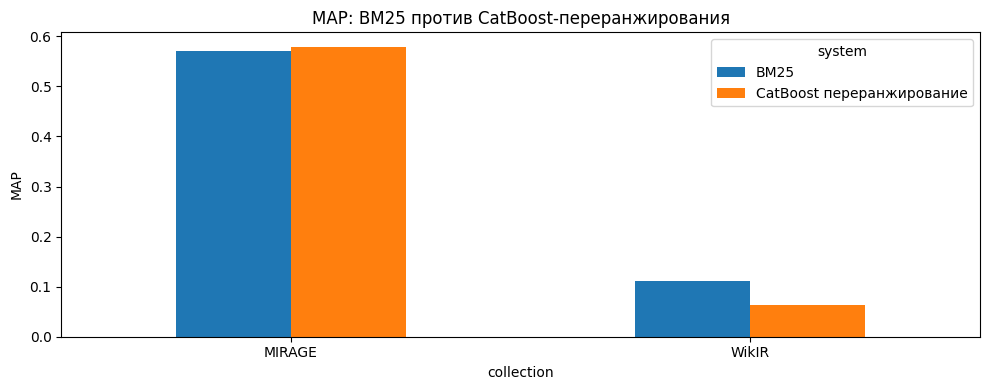

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
pivot = comparison_df.pivot(index='collection', columns='system', values='MAP')
pivot.plot(kind='bar', ax=ax, rot=0)
ax.set_title('MAP: BM25 против CatBoost-переранжирования')
ax.set_ylabel('MAP')
plt.tight_layout()
plt.show()


In [27]:
summary = {
    'msrank_results': msrank_results.to_dict(orient='records'),
    'imat_results': imat_results.to_dict(orient='records'),
    'wikir': {
        'bm25': wikir_bm25_metrics,
        'переранжирование': wikir_reranked_metrics,
        'реконструкция': wikir_reconstruct_metrics,
    },
    'mirage': {
        'bm25': mirage_bm25_metrics,
        'переранжирование': mirage_reranked_metrics,
    },
}

with open(HW3_DIR / 'hw3_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary


{'msrank_results': [{'model': 'YetiRank',
   'valid_nDCG@10': 0.5053163958932864,
   'test_nDCG@10': 0.4048615109122186},
  {'model': 'PairLogitPairwise',
   'valid_nDCG@10': 0.4866170571795105,
   'test_nDCG@10': 0.39144322631032846}],
 'imat_results': [{'model': 'YetiRank',
   'valid_nDCG@10': 0.7263556060065217,
   'test_nDCG@10': 0.7221195258355968},
  {'model': 'PairLogitPairwise',
   'valid_nDCG@10': 0.7218969880096298,
   'test_nDCG@10': 0.7205027675594295}],
 'wikir': {'bm25': {'P@1': 0.23,
   'P@10': 0.1319999999999999,
   'P@20': 0.09499999999999999,
   'MAP': 0.11196168401599797,
   'nDCG@20': 0.2160891668625118},
  'переранжирование': {'P@1': 0.19,
   'P@10': 0.06399999999999997,
   'P@20': 0.050499999999999996,
   'MAP': 0.06307532533466134,
   'nDCG@20': 0.11907488751575335},
  'реконструкция': {'P@1': 0.12,
   'P@10': 0.05199999999999999,
   'P@20': 0.040999999999999995,
   'MAP': 0.04946125358672479,
   'nDCG@20': 0.09028928449776324}},
 'mirage': {'bm25': {'P@1': 0.485

## Выводы

1. `CatBoostRanker` успешно применён к `MSRank_10K` и к `Internet Mathematics 2009`; в обоих случаях
   лучшей моделью оказался `YetiRank`. На `MSRank_10K` он дал `test nDCG@10 = 0.405`, а на
   `Internet Mathematics 2009` — `test nDCG@10 = 0.722`.
2. Преобразование `Internet Mathematics 2009` в формат `LETOR` выполнено корректно: получены файлы
   `imat2009_train_letor.txt` и `imat2009_test_letor.txt`, а также описание набора данных и распределения меток.
3. Для `WikIR` реализованы обе постановки из задания: улучшение `BM25` через дополнительные признаки
   и попытка реконструкции `BM25` по его компонентам. В полном прогоне обе модели уступили базовому
   `BM25`: лучший baseline дал `MAP = 0.112`, `nDCG@20 = 0.216`, тогда как CatBoost-модели показали
   более низкие значения.
4. Для `MIRAGE` выполнены все заявленные улучшения: разбиение на `train/test` с учётом происхождения
   вопросов, двухпольное представление документа (`title + body`), а также сбор внешних признаков
   `pageviews` и `inlinks`.
5. На `MIRAGE` переранжирование оказалось полезным: `CatBoost` превзошёл базовый `BM25` по `P@1`
   (`0.513` против `0.485`), `MAP` (`0.579` против `0.571`) и `nDCG@20` (`0.635` против `0.631`).
   Это означает, что для этой коллекции дополнительные структурные и внешние признаки действительно помогают.
6. В целом ноутбук закрывает все основные пункты задания: есть контрольный эксперимент на `MSRank_10K`,
   полноценный LTR на `Internet Mathematics 2009`, обе постановки для `WikIR` и полный эксперимент
   для `MIRAGE` с внешними wiki-сигналами.
